Load the dataset

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

Load the dataset

In [27]:
df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Check missing values

In [28]:
df.isnull().sum().sort_values(ascending=False)

artists             1
album_name          1
track_name          1
Unnamed: 0          0
mode                0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
speechiness         0
key                 0
loudness            0
track_id            0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64

Check target distribution

In [29]:
df["track_genre"].value_counts().head(20)

track_genre
acoustic         1000
afrobeat         1000
alt-rock         1000
alternative      1000
ambient          1000
anime            1000
black-metal      1000
bluegrass        1000
blues            1000
brazil           1000
breakbeat        1000
british          1000
cantopop         1000
chicago-house    1000
children         1000
chill            1000
classical        1000
club             1000
comedy           1000
country          1000
Name: count, dtype: int64

Find the 10 most common genres, then make a new dataset that only includes songs from those genres.

In [30]:
top_10 = df["track_genre"].value_counts().head(10).index.tolist()

df_filtered = df[df["track_genre"].isin(top_10)].copy()

df_small = (
    df_filtered.groupby("track_genre", group_keys=False)
    .sample(n=200, random_state=42)
    .reset_index(drop=True)
)

print(df_small.shape)
print(df_small["track_genre"].value_counts())

(2000, 21)
track_genre
acoustic       200
afrobeat       200
alt-rock       200
alternative    200
ambient        200
anime          200
black-metal    200
bluegrass      200
blues          200
brazil         200
Name: count, dtype: int64


Select numeric audio features

In [31]:
features = [
    "popularity",
    "duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]

target = "track_genre"

X = df_small[features].copy()
y = df_small[target].copy()

print(X.shape)
print(y.shape)

(2000, 14)
(2000,)


Encode genre labels

In [32]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Genres:", list(label_encoder.classes_))

Genres: ['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil']


Train/validation/test split. 700 training songs, 150 validation songs, 150 test songs.

In [33]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1400, 14)
Validation shape: (300, 14)
Test shape: (300, 14)


Scale the features

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

[0 0 0 ... 9 9 9]


Logistic Regression

We will be using softmax for multi class logistic regression.

In [ ]:
import matplotlib.pyplot as plt
import numpy as numpy
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [21]:
def logistic_model(C, solver_, multiclass_):
    logistic_regression_model = LogisticRegression(random_state=42, solver=solver_, multi_class=multiclass_, n_jobs=1, C=C)
    return logistic_regression_model


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

multiclass = ['ovr', 'multinomial']
solver_list = ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga']
c_values = [0.01, 0.1, 1, 10, 50, 100]
lr_results = []

for c in c_values:
    for i in multiclass:
        for j in solver_list:
            try:
                model = logistic_model(c, j, i)
                model.fit(X_train_scaled, y_train)

                y_train_pred = model.predict(X_train_scaled)
                y_val_pred = model.predict(X_val_scaled)

                lr_results.append({
                    "model": "Logistic Regression",
                    "multiclass": i,
                    "solver": j,
                    "C": c,
                    "train_accuracy": accuracy_score(y_train, y_train_pred),
                    "val_accuracy": accuracy_score(y_val, y_val_pred),
                    "val_precision": precision_score(y_val, y_val_pred, average="macro", zero_division=0),
                    "val_recall": recall_score(y_val, y_val_pred, average="macro", zero_division=0),
                    "val_f1": f1_score(y_val, y_val_pred, average="macro", zero_division=0)
                })

            except ValueError as e:
                print(f"Skipping C={c} | {i} + {j}: {e}")


The results table

In [37]:
# Convert to DataFrame for a clean results table
lr_results_df = pd.DataFrame(lr_results)
lr_results_df.sort_values("val_f1", ascending=False)

,model,multiclass,solver,C,train_accuracy,val_accuracy,val_precision,val_recall,val_f1
23,Logistic Regression,multinomial,newton-cg,1.00,0.595714,0.626667,0.618742,0.626667,0.615066
26,Logistic Regression,multinomial,saga,1.00,0.595000,0.626667,0.618742,0.626667,0.615066
25,Logistic Regression,multinomial,sag,1.00,0.595000,0.626667,0.618742,0.626667,0.615066
24,Logistic Regression,multinomial,lbfgs,1.00,0.595000,0.626667,0.618742,0.626667,0.615066
53,Logistic Regression,multinomial,saga,100.00,0.595714,0.623333,0.615377,0.623333,0.611544
35,Logistic Regression,multinomial,saga,10.00,0.595714,0.623333,0.615377,0.623333,0.611544
34,Logistic Regression,multinomial,sag,10.00,0.595714,0.623333,0.615377,0.623333,0.611544
32,Logistic Regression,multinomial,newton-cg,10.00,0.595714,0.623333,0.615377,0.623333,0.611544
44,Logistic Regression,multinomial,saga,50.00,0.595714,0.623333,0.615377,0.623333,0.611544
51,Logistic Regression,multinomial,lbfgs,100.00,0.597143,0.623333,0.614956,0.623333,0.611303


KNN

SVM

In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Log-tranformed features

In [36]:
X_train_log = X_train.copy()
X_val_log = X_val.copy()
X_test_log = X_test.copy()

for col in ["duration_ms", "tempo", "popularity"]:
    X_train_log[col] = np.log1p(X_train_log[col])
    X_val_log[col] = np.log1p(X_val_log[col])
    X_test_log[col] = np.log1p(X_test_log[col])

scaler_log = StandardScaler()

X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_val_log_scaled = scaler_log.transform(X_val_log)
X_test_log_scaled = scaler_log.transform(X_test_log)

PCA features

In [37]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original shape:", X_train_scaled.shape)
print("PCA shape:", X_train_pca.shape)

Original shape: (1400, 14)
PCA shape: (1400, 12)


Polynomial features

In [38]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Polynomial shape:", X_train_poly.shape)

Polynomial shape: (1400, 119)


Store the 4 feature sets

In [39]:
svm_feature_sets = {
    "original": (X_train_scaled, X_val_scaled, X_test_scaled),
    "pca": (X_train_pca, X_val_pca, X_test_pca),
    "polynomial": (X_train_poly, X_val_poly, X_test_poly),
    "log": (X_train_log_scaled, X_val_log_scaled, X_test_log_scaled)
}

In [40]:
svm_results = []
C_values = [0.01, 0.1, 1, 10, 50, 100]

for feature_name, (Xtr, Xv, Xt) in svm_feature_sets.items():
    for c in C_values:
        model = SVC(kernel="rbf", C=c, gamma="scale")
        model.fit(Xtr, y_train)

        y_train_pred = model.predict(Xtr)
        y_val_pred = model.predict(Xv)

        svm_results.append({
            "model": "SVM",
            "feature_set": feature_name,
            "C": c,
            "train_accuracy": accuracy_score(y_train, y_train_pred),
            "val_accuracy": accuracy_score(y_val, y_val_pred),
            "val_precision": precision_score(y_val, y_val_pred, average="macro", zero_division=0),
            "val_recall": recall_score(y_val, y_val_pred, average="macro", zero_division=0),
            "val_f1": f1_score(y_val, y_val_pred, average="macro", zero_division=0)
        })

The results table

In [41]:
svm_results_df = pd.DataFrame(svm_results)
print("Number of SVM models trained:", len(svm_results_df))
svm_results_df.sort_values(by="val_accuracy", ascending=False).head(24)

Number of SVM models trained: 24


,model,feature_set,C,train_accuracy,val_accuracy,val_precision,val_recall,val_f1
15,SVM,polynomial,10.00,0.875000,0.550000,0.557025,0.550000,0.548326
3,SVM,original,10.00,0.882143,0.546667,0.548995,0.546667,0.541749
20,SVM,log,1.00,0.660000,0.540000,0.542081,0.540000,0.533709
2,SVM,original,1.00,0.684286,0.540000,0.540056,0.540000,0.531712
8,SVM,pca,1.00,0.664286,0.536667,0.536175,0.536667,0.528906
9,SVM,pca,10.00,0.856429,0.536667,0.549774,0.536667,0.538744
21,SVM,log,10.00,0.874286,0.536667,0.553621,0.536667,0.537703
17,SVM,polynomial,100.00,0.972857,0.520000,0.533748,0.520000,0.520509
16,SVM,polynomial,50.00,0.957143,0.520000,0.539251,0.520000,0.521391
14,SVM,polynomial,1.00,0.695714,0.516667,0.530372,0.516667,0.515627


Validation accuracy vs C for each feature set

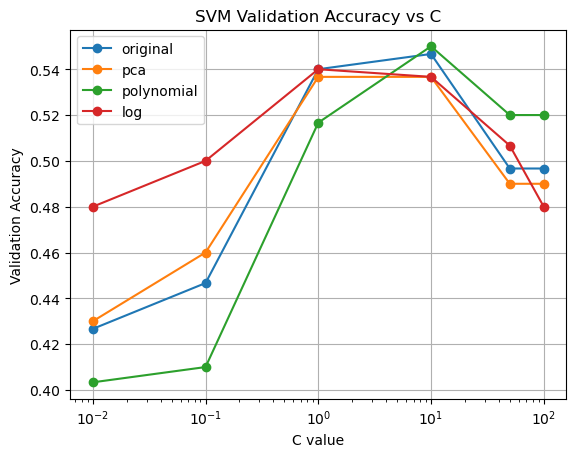

In [42]:
for feature_name in svm_results_df["feature_set"].unique():
    subset = svm_results_df[svm_results_df["feature_set"] == feature_name]
    plt.plot(subset["C"], subset["val_accuracy"], marker="o", label=feature_name)

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Validation Accuracy")
plt.title("SVM Validation Accuracy vs C")
plt.legend()
plt.grid(True)
plt.show()

Bar chart of best validation accuracy by feature set

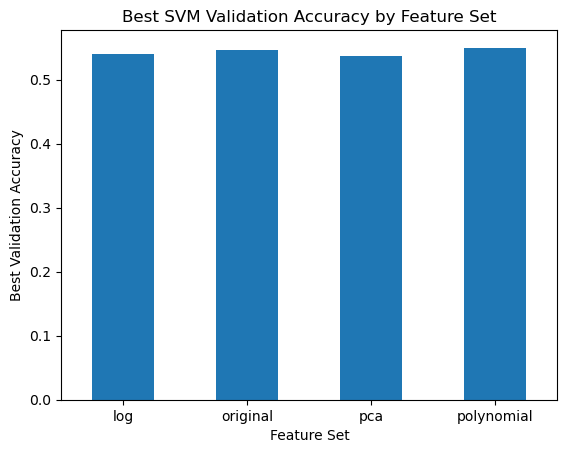

In [43]:
best_by_feature = svm_results_df.groupby("feature_set")["val_accuracy"].max()

best_by_feature.plot(kind="bar")
plt.xlabel("Feature Set")
plt.ylabel("Best Validation Accuracy")
plt.title("Best SVM Validation Accuracy by Feature Set")
plt.xticks(rotation=0)
plt.show()